## Simulation

Small notebook to run the simulation and see what is happening

#### TFIM Local magnetization

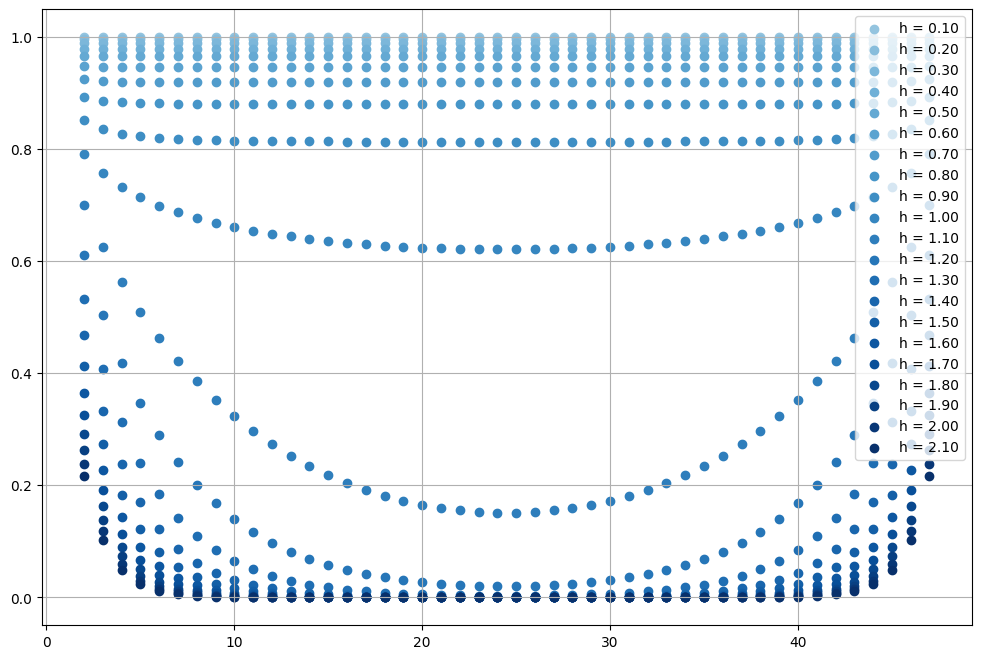

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

home = os.getcwd()
os.chdir("..")

outputs = os.path.join(os.getcwd(), "OUT/TFIM")
cor = cm.Blues(np.linspace(0.4, 1, 21))
values = []
values2 = []
h_indices = []
plt.figure(figsize=(12, 8))

for index, h_value in enumerate(sorted(os.listdir(outputs))):
    result = os.path.join(outputs, h_value)

    arr = np.loadtxt(os.path.join(result, "Z.txt")).T
    arr2 = np.loadtxt(os.path.join(result, "S.txt")).T
    values.append(min(arr[1]))
    values2.append(max(arr2[2]))
    h_indices.append(h_value.split("_")[1])
    plt.scatter(arr[0], arr[1], color=cor[index], label=f"h = {h_value.split("_")[1]}")


plt.legend(loc="upper right")
plt.grid()
plt.show()

os.chdir(home)

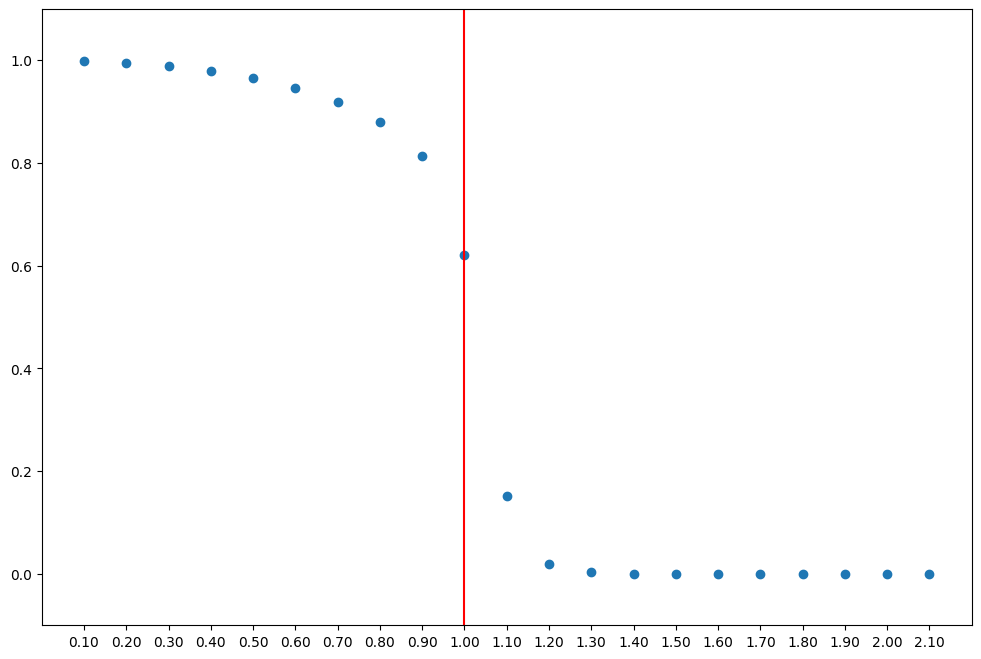

In [3]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values, label="L = 50")
plt.ylim((min(values)-.1, max(values)+.1))
plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

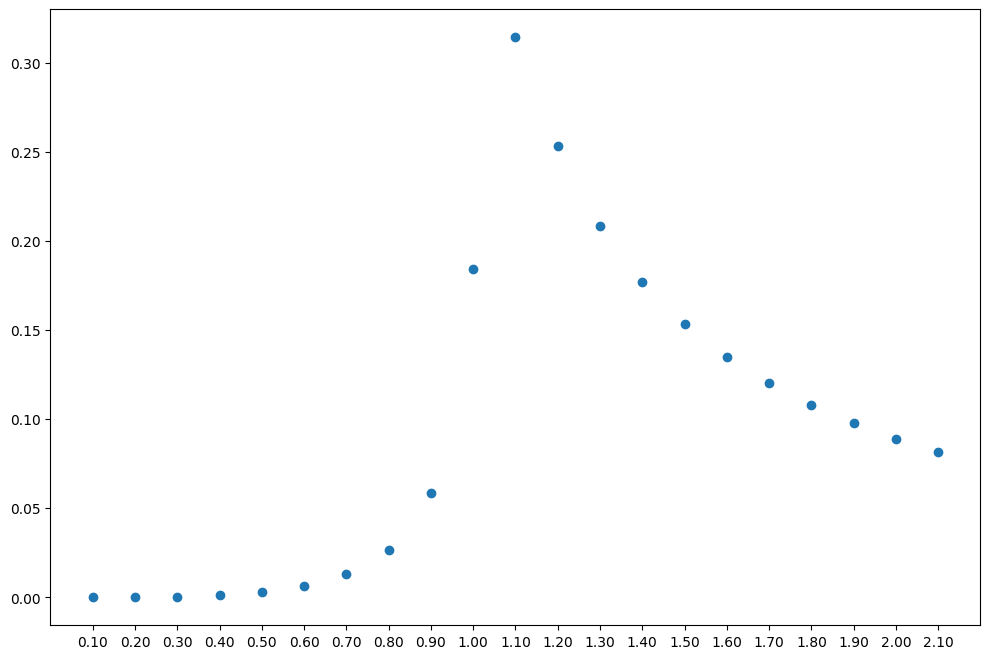

In [6]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values2, label="L = 50")
# plt.ylim((min(values)-.1, max(values2)+.1))
# plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

#### Data processing of values - Open BC

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
home = os.getcwd()
os.chdir("..")
dir = os.path.join(os.getcwd(), "OUT/First_Run")

# extract data
h_values = np.arange(0, 2.1, 0.2)
k_values = np.arange(-2, 2.1, 0.2)
results = np.zeros((len(h_values), len(k_values)))
results2 = np.zeros((len(h_values), len(k_values)))
woops = []
for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")
    
    h = float(name[1])
    k = float(name[2])
    h_idx = np.where(np.isclose(h_values, h, atol=1e-8))[0][0]
    k_idx = np.where(np.isclose(k_values, k, atol=1e-8))[0][0]

    loc = os.path.join(dir, file)
    magnetization = np.loadtxt(os.path.join(loc, "Z.txt")).T
    results[h_idx][k_idx] = min(magnetization[1])
    entropy = np.loadtxt(os.path.join(loc, "S.txt")).T
    results2[h_idx][k_idx] = max(entropy[2])

    # check convergence
    E = np.loadtxt(os.path.join(loc, "E_sweep.txt")).T

    if not np.isclose(E[-1], E.min(), atol=1e-8):
        woops.append([h, k])

# reset the home directory after each run
os.chdir(home)

##### Checking for convergence

In [9]:
# all parameter points that dont converge well
woops = np.array(woops)
if woops.shape == (0,):
    print("Everything converged!")
else:
    plt.scatter(woops[1], woops[0])

Everything converged!


##### Magnetization Plotting

##### Plotting via imshow

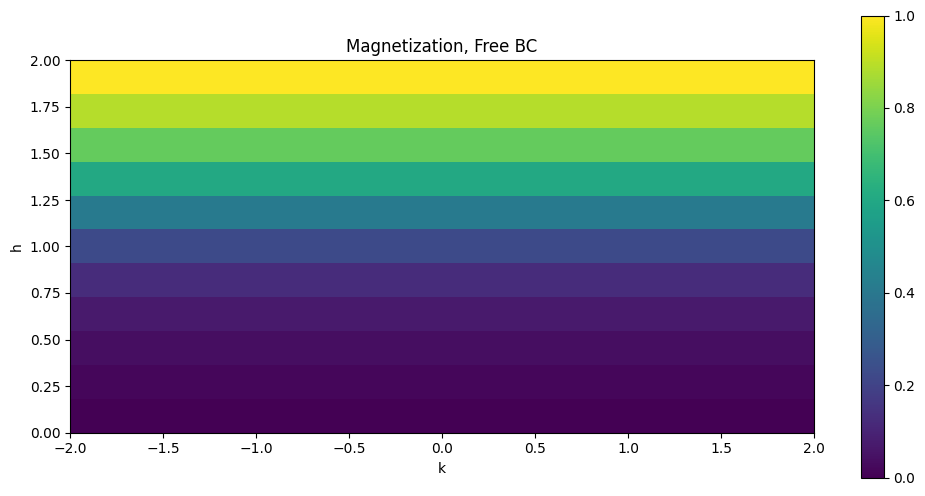

In [5]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_title("Magnetization, Free BC")
ax.set_xlabel("k")
ax.set_ylabel('h')
plt.show()

# plt.imshow(results)

##### Entanglement Entropy

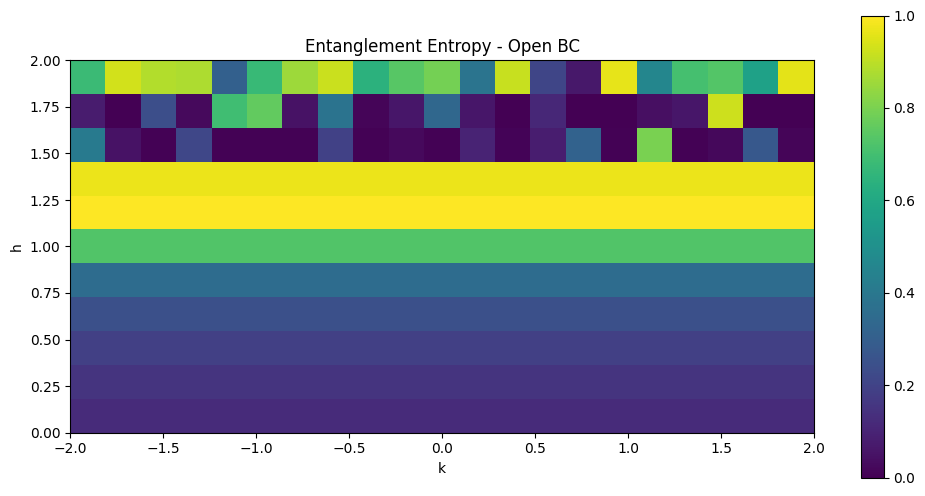

In [36]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results2, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_xlabel("k")
ax.set_ylabel('h')
ax.set_title("Entanglement Entropy - Open BC")
plt.show()


#### Data processing - Fixed X Polarization

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT

dir = os.path.join(os.getcwd(), "out_0_0.5_1/OUT")

h_values = np.array([0, 0.5, 1])
k_values = np.arange(0, 2.1, 0.1)

magnetization_real = np.zeros((len(h_values), len(k_values)))
magnetization_img = np.zeros((len(h_values), len(k_values)))
entropy = np.zeros((len(h_values), len(k_values)))

for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")

    h = float(name[1])
    k = float(name[2])
    k_idx = np.where(np.isclose(k_values, k, atol=1e-8))[0][0]
    h_idx = np.where(np.isclose(h_values, h, atol=1e-8))[0][0]

    loc = os.path.join(dir, file)

    m = np.loadtxt(os.path.join(loc, "X.txt"))
    magnetization_real[h_idx][k_idx] = np.abs(np.real((m[10][1] - m[9][1])))
    magnetization_img[h_idx][k_idx] = np.abs(np.imag((m[10][1] - m[9][1])))


    s = np.loadtxt(os.path.join(loc, "S.txt"))
    entropy[h_idx][k_idx] = (s[10][1] + m[9][1]) / 2

    # check convergence
    E = np.loadtxt(os.path.join(loc, "E_sweep.txt")).T

    if not np.isclose(E[-1], E.min(), atol=1e-8):
        woops.append([h, k])


#### Magnetization

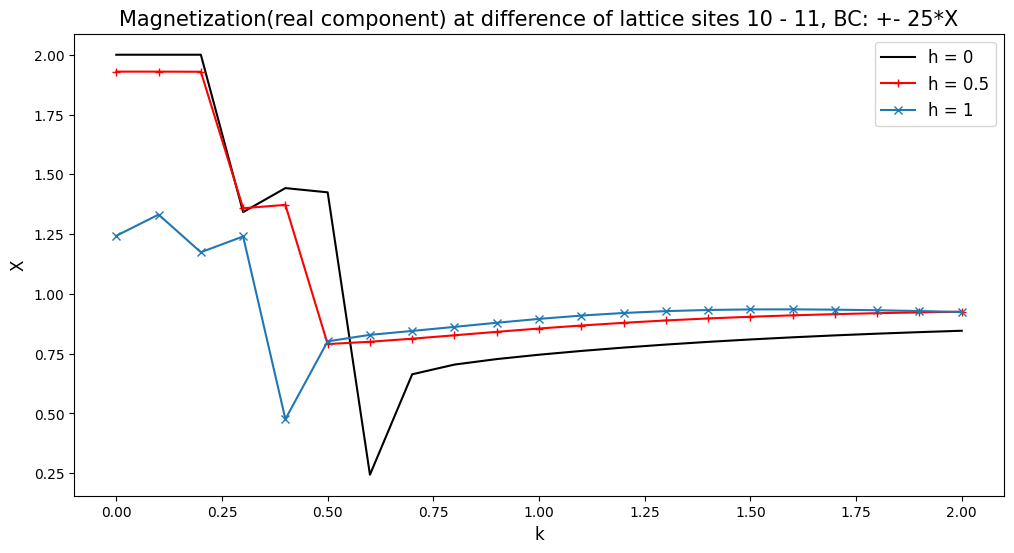

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_values, magnetization_real[0], c='black', label="h = 0")
ax.plot(k_values, magnetization_real[1], c='red',marker='+', label="h = 0.5")
ax.plot(k_values, magnetization_real[2],  marker='x',label="h = 1")

ax.set_title("Magnetization(real component) at difference of lattice sites 10 - 11, BC: +- 25*X", size=15)
ax.set_xlabel("k", size=12)
ax.set_ylabel('X', size=12)
plt.legend(fontsize=12)
plt.show()

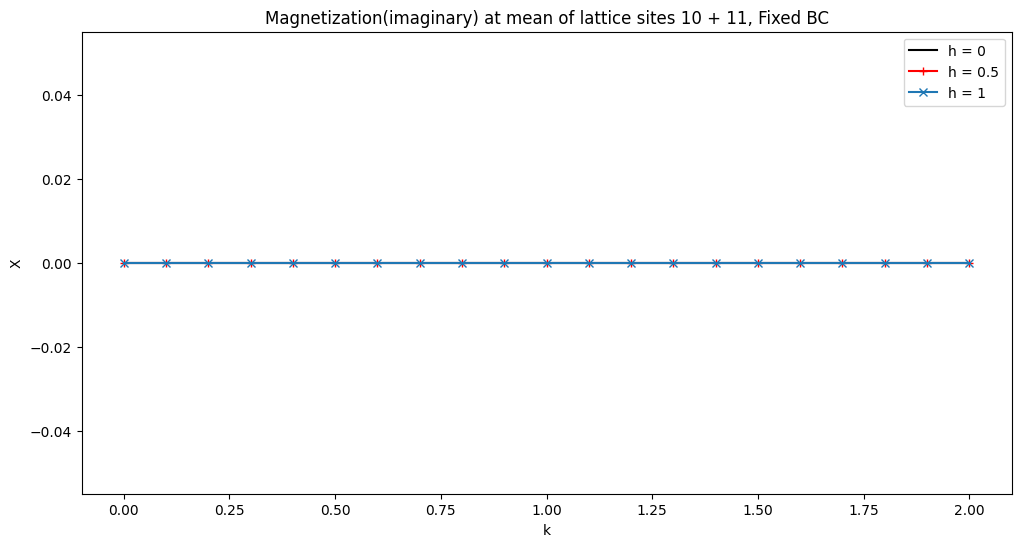

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(k_values, magnetization_img[0], c='black', label="h = 0")
ax.plot(k_values, magnetization_img[1], c='red',marker='+', label="h = 0.5")
ax.plot(k_values, magnetization_img[2],  marker='x',label="h = 1")
ax.set_title("Magnetization(imaginary) at mean of lattice sites 10 + 11, Fixed BC")
ax.set_xlabel("k")
ax.set_ylabel('X')
plt.legend()
plt.show()

#### Entropy

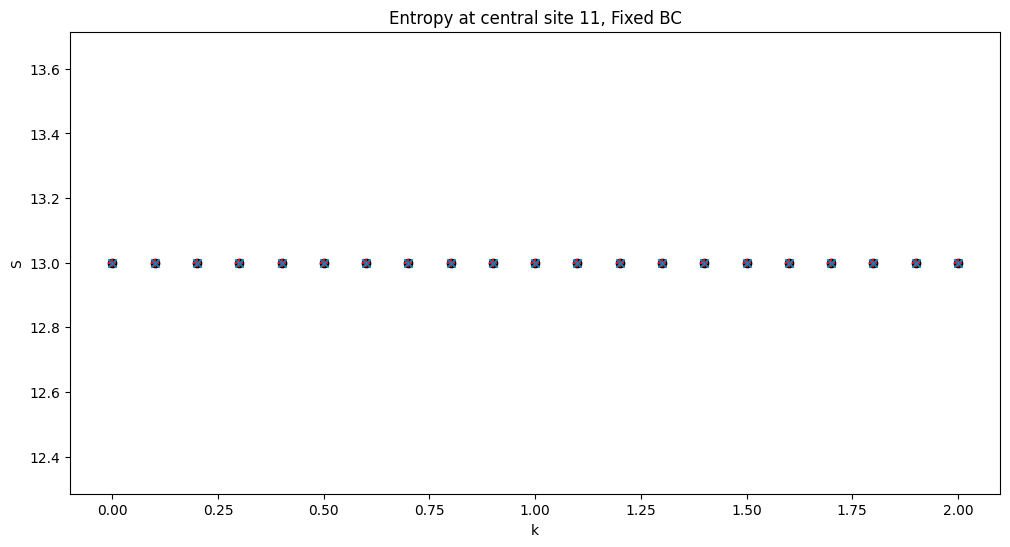

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(k_values, entropy[0], c='black', label="h = 0")
ax.scatter(k_values, entropy[1], c='red',marker='+', label="h = 0.5")
ax.scatter(k_values, entropy[2],  marker='x',label="h = 1")

ax.set_title("Entropy at central site 11, Fixed BC")
ax.set_xlabel("k")
ax.set_ylabel('S')
plt.show()


#### Correlations

/tmp/ipykernel_5078/378014820.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  xi = path_X[int(xx[0]-2)][1]
/tmp/ipykernel_5078/378014820.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  xj = path_X[int(xx[1]-2)][1]
/tmp/ipykernel_5078/378014820.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  i = int(path_X[int(xx[0]-2)][0])
/tmp/ipykernel_5078/378014820.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  j = int(path_X[int(xx[1]-2)][0])


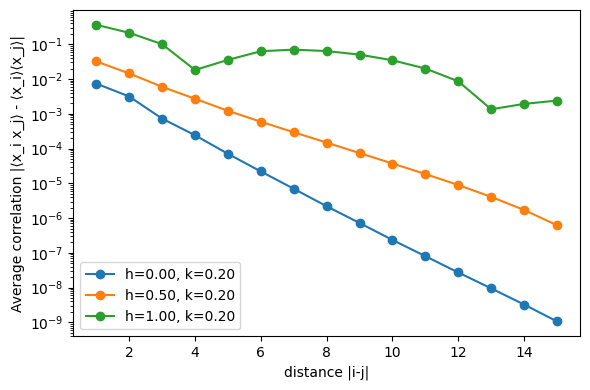

In [16]:
# define the correlation functions here:
'''
Correlation is defined as xi = <x_ix_j> - <x_i><x_j>
'''
import os
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from collections import defaultdict

# Store correlations by distance for each (h,k)
correlations_by_dist = [[defaultdict(list) for _ in range(len(k_values))] for _ in range(len(h_values))]

for h, k in product(h_values, k_values):

    k_idx = np.where(np.isclose(k_values, k, atol=1e-8))[0][0]
    h_idx = np.where(np.isclose(h_values, h, atol=1e-8))[0][0]

    path_X = np.loadtxt(os.path.join(os.getcwd(), f"out_0_0.5_1/OUT/out_{h:.2f}_{k:.2f}/X.txt"), dtype="complex")
    path_XX = np.loadtxt(os.path.join(os.getcwd(), f"out_0_0.5_1/OUT/out_{h:.2f}_{k:.2f}/XX.txt"), dtype="complex")
    
    for xx in path_XX:
        xixj = xx[2]
        try:
            xi = path_X[int(xx[0]-2)][1]
            xj = path_X[int(xx[1]-2)][1]

            i = int(path_X[int(xx[0]-2)][0])
            j = int(path_X[int(xx[1]-2)][0])
            dist = abs(i - j)

            corr_val = xixj - (xi * xj)
            correlations_by_dist[h_idx][k_idx][dist].append(corr_val)

        except IndexError:
            continue
        else:
            continue

# --- Compute averaged correlation for one (h_idx, k_idx) ---
k_idx = 2

# average over all pairs with the same distance
d1 = np.array(sorted(correlations_by_dist[0][k_idx].keys()))
C1 = np.array([np.mean(correlations_by_dist[0][k_idx][dist]) for dist in d1])

d2 = np.array(sorted(correlations_by_dist[1][k_idx].keys()))
C2 = np.array([np.mean(correlations_by_dist[1][k_idx][dist]) for dist in d2])

d3 = np.array(sorted(correlations_by_dist[2][k_idx].keys()))
C3 = np.array([np.mean(correlations_by_dist[2][k_idx][dist]) for dist in d3])

# Filter out zero / empty values
# mask = (d > 0) & (np.abs(C) > 1e-12)
# d = d[mask]
# C = C[mask]

# Plot averaged correlation
plt.figure(figsize=(6,4))
plt.semilogy(d1, np.abs(C1), "o-", label=f"h={h_values[0]:.2f}, k={k_values[k_idx]:.2f}")
plt.semilogy(d2, np.abs(C2), "o-", label=f"h={h_values[1]:.2f}, k={k_values[k_idx]:.2f}")
plt.semilogy(d3, np.abs(C3), "o-", label=f"h={h_values[2]:.2f}, k={k_values[k_idx]:.2f}")


plt.xlabel("distance |i-j|")
plt.ylabel("Average correlation |⟨x_i x_j⟩ - ⟨x_i⟩⟨x_j⟩|")
plt.legend()
plt.tight_layout()
plt.show()


#### SANITY CHECK

In [58]:
path = os.path.join(os.getcwd(), "../1_0/OUT/out_1.00_0.00")
pathx10 = os.path.join(os.getcwd(), "../2_0/OUT/out_2.00_0.00")

energy = np.loadtxt(os.path.join(path, 'E_sweep.txt'))
energyx10 = np.loadtxt(os.path.join(pathx10, 'E_sweep.txt'))

print(energy)
print(energyx10)
print(energyx10[-1]/ energy[-1] )

[-73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658 -73.70435658 -73.70435658 -73.70435658
 -73.70435658 -73.70435658]
[-88.8782119 -88.8782119 -88.8782119 -88.8782119 -88.8782119 -88.8782119
 -88.8782119 -88.8782119 -88.8782119 -88.8782119 -88.8782119 -88.8782119
 -88.8782119 -88.8782119 -88.8782119 -88.8782119 -88.8782119 -88.8782119
 -88.8782119 -88.8782119 -8

## GRAVEYARD

/tmp/ipykernel_4993/2788731697.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  mean_by_site = {int(row[0]): row[1] for row in X}
/tmp/ipykernel_4993/2788731697.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  i = int(i_idx); j = int(j_idx)


(h=0.00, k=0.30)  best fit: power-law
  power-law: A=0.246, eta=0.739,  AIC=-50.99
  exponential: A=0.145, xi=8.12, AIC=-49.81


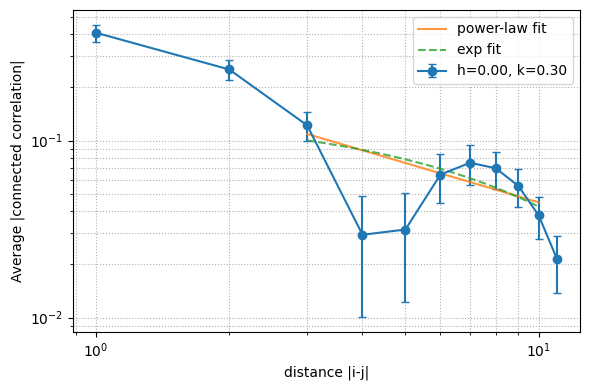

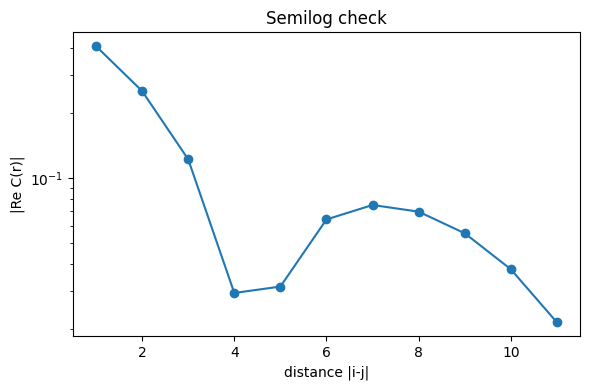

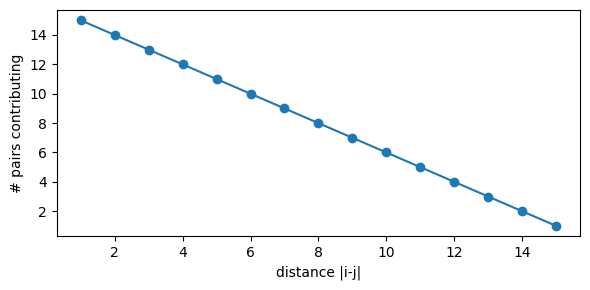

In [11]:
import os
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit

# --- build: collect all connected correlators by distance for each (h,k) ---
correlations_by_dist = [[defaultdict(list) for _ in range(len(k_values))] for _ in range(len(h_values))]

for h, k in product(h_values, k_values):
    k_idx = int(np.where(np.isclose(k_values, k, atol=1e-8))[0][0])
    h_idx = int(np.where(np.isclose(h_values, h, atol=1e-8))[0][0])

    path = f"out_0_0.5_1/OUT/out_{h:.2f}_{k:.2f}"
    X  = np.loadtxt(os.path.join(os.getcwd(), path, "X.txt" ), dtype="complex")
    XX = np.loadtxt(os.path.join(os.getcwd(), path, "XX.txt"), dtype="complex")

    # Map site index -> <x_i>
    # Assumes X rows are [i, <x_i>]
    # If your indices start at 2 in files, we keep using them directly.
    mean_by_site = {int(row[0]): row[1] for row in X}

    for i_idx, j_idx, xixj in XX:
        i = int(i_idx); j = int(j_idx)
        if i not in mean_by_site or j not in mean_by_site: 
            continue
        xi = mean_by_site[i]
        xj = mean_by_site[j]
        dist = abs(i - j)
        if dist == 0: 
            continue  # skip self-pairs
        corr_val = xixj - (xi * xj)
        correlations_by_dist[h_idx][k_idx][dist].append(corr_val)

# --- choose parameter point to analyze ---

h_idx = int(np.argmin(np.abs(h_values - 0.00)))  # adjust as desired
k_idx = int(np.argmin(np.abs(k_values - 0.30)))

# --- aggregate: mean, stderr, counts (use real part; inspect imag separately if needed) ---
d_sorted = np.array(sorted(correlations_by_dist[h_idx][k_idx].keys()))
vals = [np.array(correlations_by_dist[h_idx][k_idx][d]) for d in d_sorted]

C_mean = np.array([np.mean(np.real(v)) for v in vals])
C_std  = np.array([np.std (np.real(v), ddof=1) if len(v)>1 else 0.0 for v in vals])
N_pairs= np.array([len(v) for v in vals])
C_sem  = np.where(N_pairs>0, C_std/np.sqrt(N_pairs), 0.0)

# filter distances with at least, say, 5 pairs
keep = (N_pairs >= 5)
r = d_sorted[keep]
C = C_mean[keep]
E = C_sem[keep]

# --- fit window (exclude small-r lattice artifacts and noisy tail) ---
# pick a window automatically based on where |C| is between percentiles
if len(r) >= 6:
    mag = np.abs(C)
    lo, hi = np.percentile(mag, [20, 80])
    fit_mask = (mag >= lo) & (mag <= hi)
else:
    fit_mask = np.ones_like(r, dtype=bool)

r_fit = r[fit_mask]
C_fit = C[fit_mask]

# models
def power_law(rr, A, eta):      # C ~ A * r^{-eta}
    return A * rr**(-eta)

def exponential(rr, A, xi):     # C ~ A * exp(-r/xi)
    return A * np.exp(-rr/xi)

def fit_model(func, x, y, p0):
    try:
        popt, pcov = curve_fit(func, x, y, p0=p0, maxfev=10000)
        resid = y - func(x, *popt)
        sse = np.sum(resid**2)
        k = len(popt)
        n = len(y)
        aic = n*np.log(sse/n + 1e-300) + 2*k if n>k else np.inf
        return popt, aic, sse
    except Exception:
        return None, np.inf, np.inf

pl_popt, pl_aic, pl_sse = fit_model(power_law,   r_fit, np.abs(C_fit), p0=[C_fit[0], 1.0])
ex_popt, ex_aic, ex_sse = fit_model(exponential, r_fit, np.abs(C_fit), p0=[C_fit[0], max(2.0, r_fit.mean())])

model_choice = "power-law" if pl_aic < ex_aic else "exponential"

print(f"(h={h_values[h_idx]:.2f}, k={k_values[k_idx]:.2f})  best fit: {model_choice}")
if pl_popt is not None:
    print(f"  power-law: A={pl_popt[0]:.3g}, eta={pl_popt[1]:.3g},  AIC={pl_aic:.2f}")
if ex_popt is not None:
    print(f"  exponential: A={ex_popt[0]:.3g}, xi={ex_popt[1]:.3g}, AIC={ex_aic:.2f}")

# --- plots ---
fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(r, np.abs(C), yerr=E, fmt='o-', capsize=3, label=f"h={h_values[h_idx]:.2f}, k={k_values[k_idx]:.2f}")
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("distance |i-j|")
ax.set_ylabel("Average |connected correlation|")
ax.legend()
ax.grid(True, which='both', ls=':')

# overlay fits on the same window
rr = np.linspace(r_fit.min(), r_fit.max(), 200)
if pl_popt is not None:
    ax.plot(rr, power_law(rr, *pl_popt), '-', alpha=0.8, label="power-law fit")
if ex_popt is not None:
    ax.plot(rr, exponential(rr, *ex_popt), '--', alpha=0.8, label="exp fit")
ax.legend()
plt.tight_layout()
plt.show()

# Optional: also inspect sign-preserving real part on semilog for exponential behavior
plt.figure(figsize=(6,4))
plt.semilogy(r, np.abs(np.real(C)), 'o-')
plt.xlabel("distance |i-j|"); plt.ylabel("|Re C(r)|"); plt.title("Semilog check")
plt.tight_layout(); plt.show()

# Optional: how many pairs per distance?
plt.figure(figsize=(6,3))
plt.plot(d_sorted, N_pairs, 'o-')
plt.xlabel("distance |i-j|"); plt.ylabel("# pairs contributing")
plt.tight_layout(); plt.show()
